In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('Algerian_forest_fires_cleaned.csv')

In [32]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0


In [33]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='str')

In [34]:
df.drop(['month','day','year'], axis=1, inplace=True)

In [35]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0


In [36]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [37]:
#independent and dependent features
x = df.drop('FWI',axis=1) # dependent
y = df['FWI'] # indepentend

In [38]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0.0


In [39]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=7)

In [40]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((182, 11), (61, 11), (182,), (61,))

In [41]:
# feature selection based on correlation
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
Temperature,1.000000,-0.643426,-0.324064,-0.342103,0.678594,0.490360,0.361785,0.597964,0.457249,0.490840,0.260519
RH,-0.643426,1.000000,0.273881,0.220810,-0.643340,-0.409744,-0.209872,-0.693467,-0.349156,-0.417675,-0.372201
Ws,-0.324064,0.273881,1.000000,0.179940,-0.197647,-0.013396,0.065839,-0.015625,0.020712,-0.073332,-0.252600
Rain,-0.342103,0.220810,0.179940,1.000000,-0.547619,-0.293242,-0.293494,-0.337125,-0.302281,-0.364094,-0.039577
FFMC,0.678594,-0.643340,-0.197647,-0.547619,1.000000,0.622185,0.486454,0.736133,0.600492,0.760721,0.232260
DMC,0.490360,-0.409744,-0.013396,-0.293242,0.622185,1.000000,0.855541,0.662069,0.979147,0.600392,0.205128
DC,0.361785,-0.209872,0.065839,-0.293494,0.486454,0.855541,1.000000,0.431966,0.929318,0.485729,-0.077587
ISI,0.597964,-0.693467,-0.015625,-0.337125,0.736133,0.662069,0.431966,1.000000,0.608853,0.735057,0.291239
BUI,0.457249,-0.349156,0.020712,-0.302281,0.600492,0.979147,0.929318,0.608853,1.000000,0.592636,0.097021
Classes,0.490840,-0.417675,-0.073332,-0.364094,0.760721,0.600392,0.485729,0.735057,0.592636,1.000000,0.206542


<Axes: >

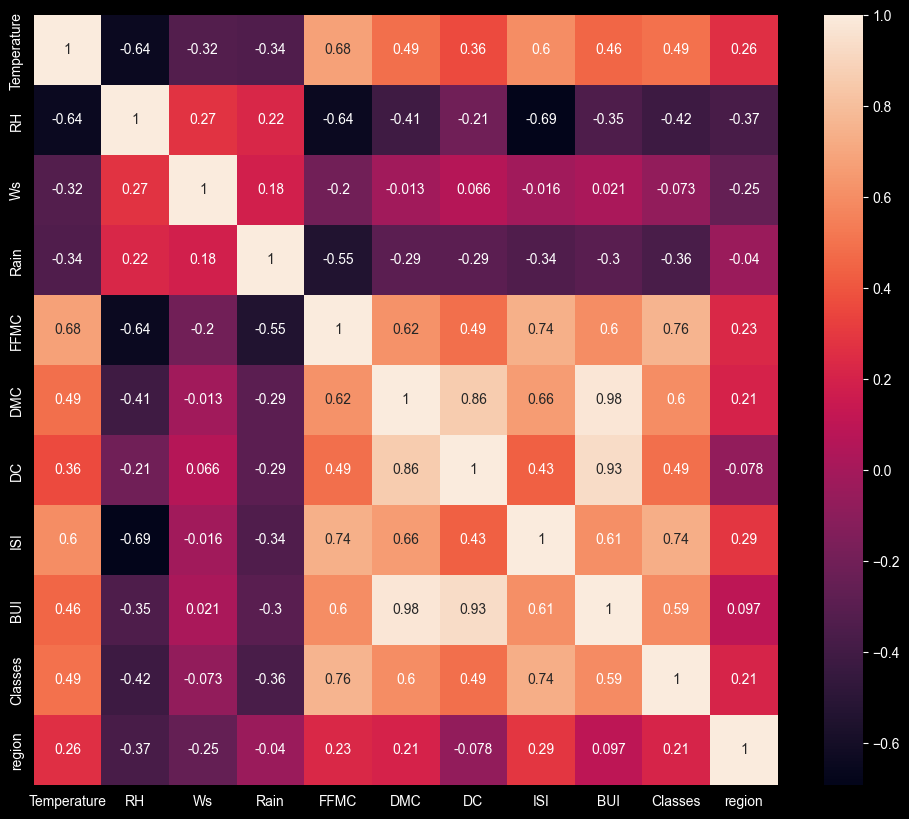

In [42]:
plt.figure(figsize=(12,10))
corr = x_train.corr()
sns.heatmap(corr, annot=True)

In [43]:
def correlation(dataset,threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                col_corr.add(corr_matrix.columns[i])
    return col_corr


In [44]:
corr_features = correlation(x_train,0.85)

In [45]:
# drop the features when correlation is more than .85
x_train.drop(corr_features,axis=1,inplace=True)
x_test.drop(corr_features,axis=1,inplace=True)
x_train.shape,x_test.shape

((182, 9), (61, 9))

## Feature scaling or standardization

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [47]:
x_train_scaled

array([[-1.47439426,  0.88104171,  1.31829252, ..., -0.90852102,
        -1.06825862, -1.04496604],
       [-0.91360062,  0.21624241,  1.31829252, ..., -0.74255374,
        -1.06825862, -1.04496604],
       [ 0.76878029, -0.44855689, -0.48027749, ...,  0.65631329,
         0.93610291, -1.04496604],
       ...,
       [-0.35280699,  0.14976248,  0.95857852, ...,  0.49034601,
         0.93610291, -1.04496604],
       [ 0.76878029, -1.04687626, -0.83999149, ..., -0.26836153,
         0.93610291,  0.9569689 ],
       [ 1.89036756,  0.14976248, -2.2788475 , ..., -0.83739218,
        -1.06825862,  0.9569689 ]], shape=(182, 9))

## Box plot to understand effect of standard scalar

Text(0.5, 1.0, 'X_train after scaling')

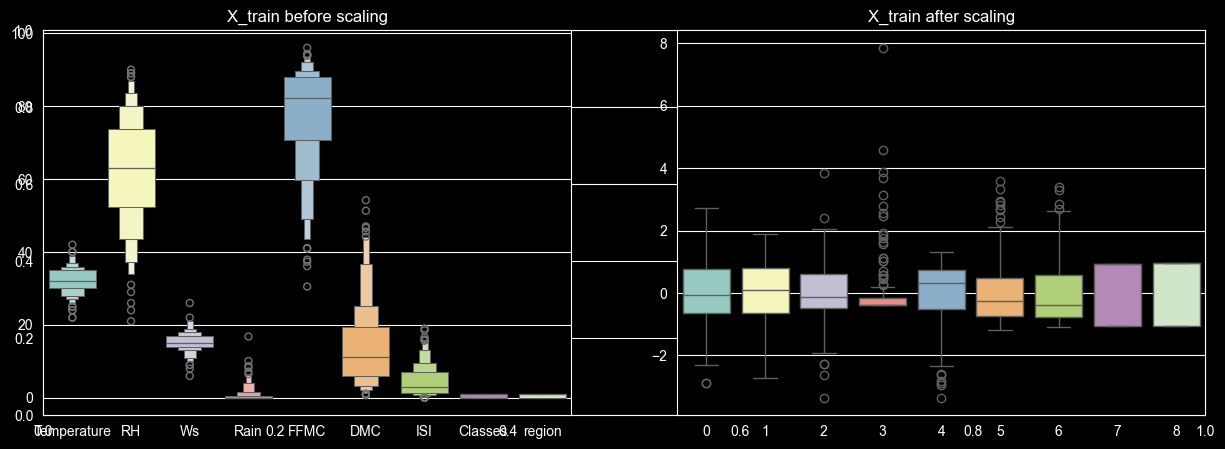

In [48]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxenplot(data=x_train)
plt.title("X_train before scaling")
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title("X_train after scaling")

## Linear Regression Model

MAE:  0.7652308247617005
R2 Score:  0.9830442748123898


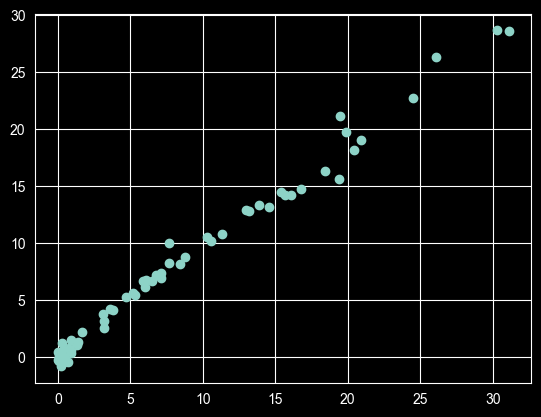

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg = LinearRegression()
linreg.fit(x_train_scaled,y_train)
y_pred = linreg.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('MAE: ',mae)
print('R2 Score: ',score)
plt.scatter(y_test,y_pred)

## Lasso Regression

MAE:  1.5085737284720486
R2 Score:  0.9312816543178952


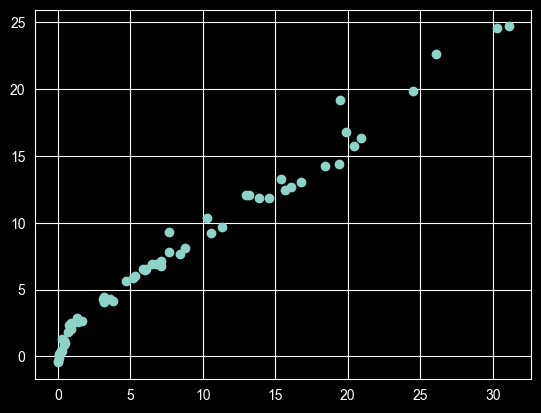

In [55]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso = Lasso()
lasso.fit(x_train_scaled,y_train)
y_pred = lasso.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('MAE: ',mae)
print('R2 Score: ',score)
plt.scatter(y_test,y_pred)

## cross validation Lasso

In [60]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(x_train_scaled,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [61]:
lassocv.predict(x_test_scaled)

array([14.74933125,  0.93442448, -0.03895128, 21.095733  ,  3.0229098 ,
        5.5569135 , -0.55175179, 19.57007755, -0.08851581,  8.80865628,
       -0.03957658, 18.04302273,  8.17223379, 12.88117702, 16.21388809,
        4.08472662,  5.18485227, -0.13817064,  7.12103602, -0.35780948,
       -0.18849254,  0.53362238,  1.30626136, 10.61372834,  3.6779177 ,
       14.16757307, 18.89776543, 28.44380394, -0.89828844,  8.14919245,
       14.16475962,  6.62192464,  7.47217129,  0.09789465,  6.14849394,
        6.76356174,  1.10363342, 10.17621815, 13.28519441, 26.18305866,
       -0.36773456,  3.28721169, 10.7861045 , 12.97317723, 15.75142161,
        6.7270489 ,  4.21014193, -0.39558914,  5.54493249,  7.26620003,
       28.439882  , 22.55946299, 13.09586962,  2.21555064,  0.64530092,
        0.87473562,  1.66486066,  1.43822422,  9.99383569, 14.31259354,
       -0.25971813])

In [64]:
lassocv.alpha_

np.float64(0.026496607694277523)

In [63]:
lassocv.alphas_

array([6.56341204, 6.12106004, 5.70852108, 5.32378586, 4.96498051,
       4.63035744, 4.31828685, 4.02724877, 3.75582568, 3.5026956 ,
       3.26662564, 3.04646601, 2.84114439, 2.64966077, 2.4710825 ,
       2.30453981, 2.14922154, 2.0043712 , 1.86928329, 1.74329985,
       1.62580728, 1.51623331, 1.41404426, 1.31874241, 1.22986358,
       1.14697489, 1.06967263, 0.99758027, 0.9303467 , 0.86764445,
       0.80916811, 0.75463289, 0.70377316, 0.6563412 , 0.612106  ,
       0.57085211, 0.53237859, 0.49649805, 0.46303574, 0.43182869,
       0.40272488, 0.37558257, 0.35026956, 0.32666256, 0.3046466 ,
       0.28411444, 0.26496608, 0.24710825, 0.23045398, 0.21492215,
       0.20043712, 0.18692833, 0.17432999, 0.16258073, 0.15162333,
       0.14140443, 0.13187424, 0.12298636, 0.11469749, 0.10696726,
       0.09975803, 0.09303467, 0.08676444, 0.08091681, 0.07546329,
       0.07037732, 0.06563412, 0.0612106 , 0.05708521, 0.05323786,
       0.04964981, 0.04630357, 0.04318287, 0.04027249, 0.03755

In [65]:
lassocv.mse_path_

array([[49.5552706 , 36.79100337, 65.68739914, 36.50117423, 56.72598273],
       [43.87830678, 32.24908599, 65.68739914, 31.93813558, 52.06072772],
       [39.05044313, 28.3272454 , 58.36667746, 28.08098057, 46.76825661],
       [34.83117367, 24.94279601, 52.48289363, 24.83024951, 42.13306019],
       [30.98967973, 21.63175478, 47.29690925, 22.07935167, 38.07168952],
       [27.21683227, 18.75971341, 42.72245659, 19.26566922, 34.31201176],
       [23.92997491, 16.27376121, 38.25680203, 16.86742483, 30.50300947],
       [21.06609935, 14.12280241, 33.7684143 , 14.82710303, 27.16160406],
       [18.57027631, 12.26230288, 29.84216032, 13.09501414, 24.22866139],
       [16.39525827, 10.65402041, 26.40610629, 11.62814757, 21.65278214],
       [14.49937332,  9.26429947, 23.39849475, 10.38928786, 19.38914037],
       [12.84654469,  8.06406006, 20.76448822,  9.3459665 , 17.39830882],
       [11.40537587,  7.02805124, 18.45664664,  8.47094504, 15.64686299],
       [10.14854212,  6.13434951, 16.4

MAE:  0.7628110212164096
R2 Score:  0.9824865181011864


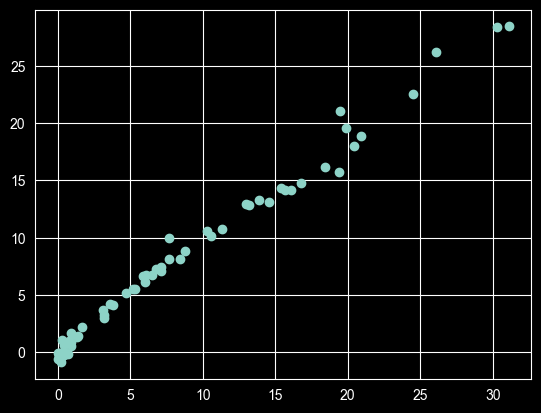

In [67]:
y_pred = lassocv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('MAE: ',mae)
print('R2 Score: ',score)

## Ridge Regression

MAE:  0.7812514758635611
R2 Score:  0.9824042844794716


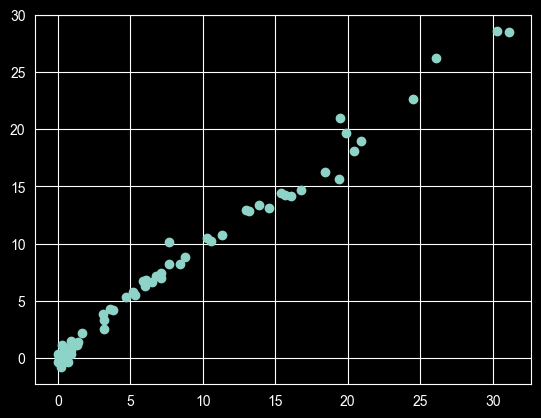

In [56]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge = Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred = ridge.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('MAE: ',mae)
print('R2 Score: ',score)
plt.scatter(y_test,y_pred)

MAE:  0.7812514758635611
R2 Score:  0.9824042844794716


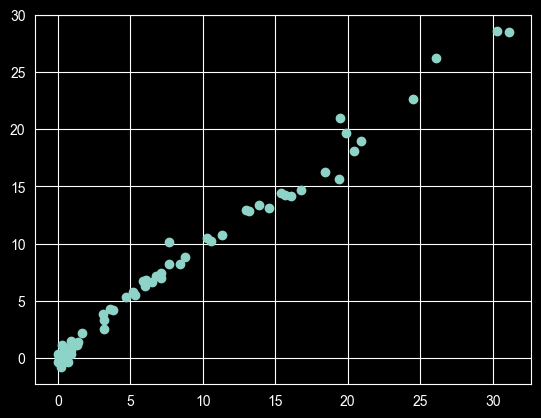

In [69]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(x_train_scaled,y_train)
y_pred = ridgecv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('MAE: ',mae)
print('R2 Score: ',score)

## Elastic Net

MAE:  2.2680354092792836
R2 Score:  0.8585725645845956


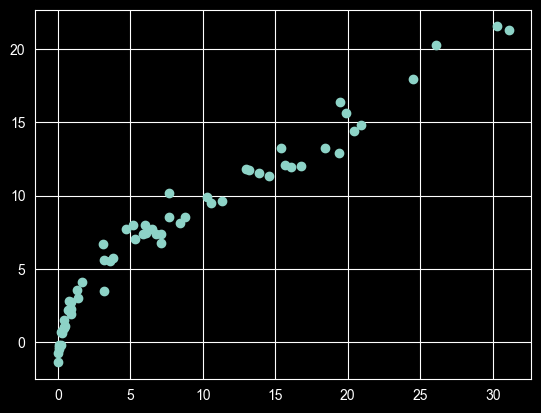

In [57]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic = ElasticNet()
elastic.fit(x_train_scaled,y_train)
y_pred = elastic.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('MAE: ',mae)
print('R2 Score: ',score)
plt.scatter(y_test,y_pred)